# 11 &middot; Mass Springs: from Hooke's Law to a Sagging Cable

The spring is the simplest elastic element: two point masses joined by one edge. We derive
Hooke's law from the spring energy, give the spring a mass and compare Forward Euler, Backward
Euler and BDF2 in *phase space*, then chain many springs into a cable and let it sag under
gravity, once by minimizing its energy and once by stepping it through time.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
from simkit.solvers import newton_solver
import utils

NOTEBOOK = "011_mass_springs"                                      # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)                # results/011_mass_springs/
MEDIA_DIR = "media"                                                # tracked copies for the website

# 1 · single spring (node 0 is a fixed anchor, node 1 a free mass)
SPRING_L0 = 1.0               # rest length l0
K_SPRING = 1.0                # spring stiffness k (simkit's `ym`)
CURVE_L_RANGE = (0.02, 2.0)   # spring lengths for the energy / force curves
N_CURVE = 200                 # samples along those curves
SWEEP_L_RANGE = (0.1, 1.9)    # collapse / stretch range of the animation
N_SWEEP = 45                  # animation frames each way
FPS = 20                      # frame rate of the spring videos and the comparison video

# 2 · oscillator
MASS = 1.0                    # mass of the free node
U0 = 0.3                      # initial stretch u = l - l0, released from rest
DT_OSC = 0.1                  # coarse time step, so the schemes visibly differ
N_PERIODS = 3                 # simulated oscillation periods
OSC_FRAMES = 90               # frames in the oscillator video
SCHEMES = ["Forward Euler", "Backward Euler", "BDF2"]

# 3 · cable
N_NODES = 21                  # masses along the cable
CABLE_LENGTH = 4.0            # rest length of the whole cable
K_CABLE = 400.0               # stiffness k of every cable spring
RHO = 1.0                     # mass per unit rest length
GRAVITY = -9.8                # vertical acceleration
K_PIN = 1e5                   # soft-pin penalty stiffness at both ends
NEWTON_TOL = 1e-9             # step-size tolerance of the static Newton solve
NEWTON_MAX_ITERS = 50         # iteration cap of the static Newton solve
DT = 0.04                     # time step of the dynamic run
N_STEPS = 250                 # Backward-Euler steps
STEP_ITERS = 20               # Newton iterations per time step
STEP_TOL = 1e-6               # step-size tolerance of each time step's Newton solve
MONOTONE_TOL = 1e-6           # round-off allowance of the "total energy never increases" check
CABLE_FPS = 40                # frame rate of the dynamic cable video (one frame per step)
NEWTON_FPS = 2                # frame rate of the Newton-iterate video
COMPARE_FRAMES = 80           # frames in the static-vs-dynamic comparison video
FD_STEP = 1e-5                # central-difference step of the gradient check
FD_NOISE = 0.1                # size of the random state used by the gradient check
SEED = 0                      # random seed of that state
K_SWEEP = [100.0, 400.0, 1600.0]   # spring stiffnesses of the parameter study
CABLE_LIMS = ((-0.5, 4.5), (-2.6, 0.5))   # plot window of every cable figure

The notebook's two spring networks, drawn at rest (blue squares are pinned): a single spring
whose node 0 is a fixed anchor (sections 1 and 2), and a cable of `N_NODES` masses pinned at both
ends (section 3).

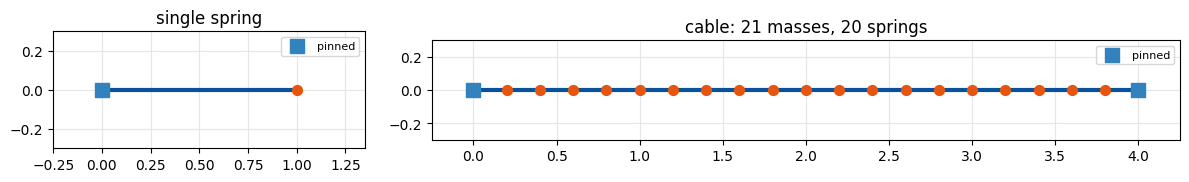

In [2]:
X_spring = np.array([[0.0, 0.0], [SPRING_L0, 0.0]])   # node 0: anchor, node 1: free mass
E_spring = np.array([[0, 1]])
anchor = X_spring[:1]

X = np.column_stack([np.linspace(0.0, CABLE_LENGTH, N_NODES), np.zeros(N_NODES)])
E = np.column_stack([np.arange(N_NODES - 1), np.arange(1, N_NODES)])   # spring e joins nodes e, e+1
pin_idx = np.array([0, N_NODES - 1])
n, dim = X.shape

fig, (ax_s, ax_c) = plt.subplots(1, 2, figsize=(12, 2.4), gridspec_kw={"width_ratios": [1, 2.4]})
utils.plot_spring_network(ax_s, X_spring, E_spring, pins=[0], node_size=50, lw=3,
                          title="single spring", lims=((-0.25, 1.35), (-0.3, 0.3)))
utils.plot_spring_network(ax_c, X, E, pins=pin_idx, node_size=50, lw=3,
                          title=f"cable: {N_NODES} masses, {len(E)} springs",
                          lims=((-0.25, CABLE_LENGTH + 0.25), (-0.3, 0.3)))
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_meshes.png"))
plt.show()

## 1 &middot; The elastic energy of a single spring (Hooke's law)

A spring stores energy through its edge vector $d = x_j - x_i$ (blind to translation), its length
$l = \lVert d\rVert$ (blind to rotation) and its stretch $l - l_0$. Differentiating the quadratic
energy gives the force, linear in the stretch and pointing back to rest: Hooke's law is derived,
not assumed.

$$
\psi = \tfrac12\,k\,(l-l_0)^2, \qquad f = -\frac{d\psi}{dl} = -k\,(l-l_0).
$$

`anchored_spring_system` turns that one spring into a mechanical system in the free mass's
position $x \in \mathbb{R}^2$; the anchor is not a degree of freedom. It builds $\psi$ and its
derivatives from simkit's per-edge `mass_springs_*_element_d`, whose `ym` is the stiffness $k$
itself (no rest-length normalization). Sections 1 and 2 hand its three functions to plots,
integrators and Newton.

In [3]:
def anchored_spring_system(anchor, k, l0):
    """One spring from a fixed `anchor` to a free mass at x (2 DOFs): psi = 1/2 k (|x - anchor| - l0)^2."""
    ym = np.array([[k]])
    rest_length = np.array([[l0]])

    def energy_func(x):
        d = x.reshape(1, 2) - anchor                                   # edge vector
        E_spring = simkit.energies.mass_springs_energy_element_d(d, ym, rest_length).item()
        E_total = E_spring
        return E_total

    def gradient_func(x):
        d = x.reshape(1, 2) - anchor
        g_spring = simkit.energies.mass_springs_gradient_element_d(d, ym, rest_length).reshape(-1, 1)
        g_total = g_spring
        return g_total

    def hessian_func(x):
        d = x.reshape(1, 2) - anchor
        H_spring = simkit.energies.mass_springs_hessian_element_d(d, ym, rest_length)[0]
        H_total = H_spring
        return H_total

    return energy_func, gradient_func, hessian_func

Slide the free mass along the axis from nearly collapsed to twice the rest length, reading the
energy from `energy_func` and the force from `-gradient_func`. The printed deviations from the
closed forms above are round-off; the plots show a parabola about $l_0$ and a straight force line
crossing zero at $l_0$.

max |psi - k(l-l0)^2/2| = 0.0e+00,  max |f + k(l-l0)| = 1.1e-16


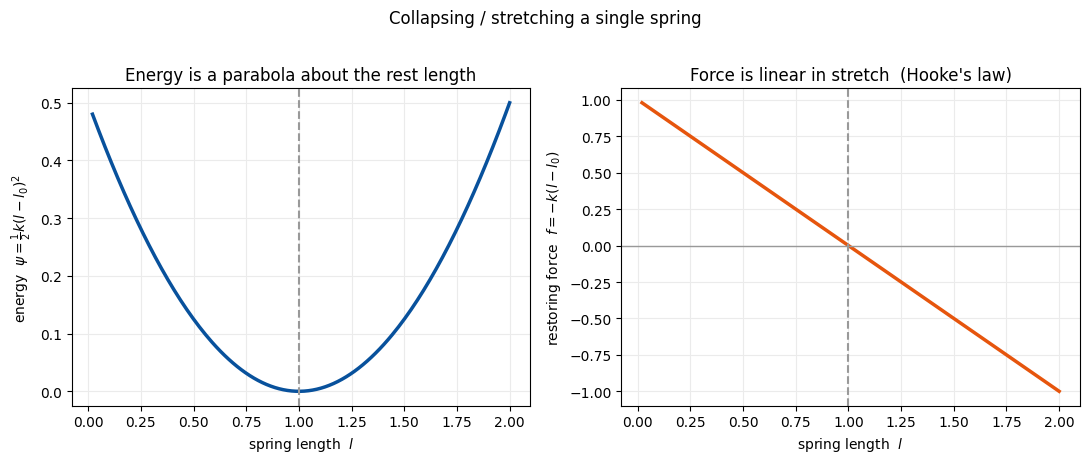

In [4]:
energy_func, gradient_func, hessian_func = anchored_spring_system(anchor, K_SPRING, SPRING_L0)

lengths = np.linspace(*CURVE_L_RANGE, N_CURVE)
psi, force = [], []
for l in lengths:
    x = np.array([[l], [0.0]])
    psi.append(energy_func(x))
    force.append(-gradient_func(x)[0, 0])                 # axial force on the free mass
psi, force = np.array(psi), np.array(force)
print(f"max |psi - k(l-l0)^2/2| = {np.abs(psi - 0.5 * K_SPRING * (lengths - SPRING_L0) ** 2).max():.1e},  "
      f"max |f + k(l-l0)| = {np.abs(force + K_SPRING * (lengths - SPRING_L0)).max():.1e}")

fig, (ax_e, ax_f) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_e.plot(lengths, psi, color=utils.SPRING_EDGE, lw=2.5)
ax_e.axvline(SPRING_L0, color="0.6", ls="--", lw=1.5)
ax_e.set_xlabel("spring length  $l$")
ax_e.set_ylabel(r"energy  $\psi=\frac{1}{2}k(l-l_0)^2$")
ax_e.set_title("Energy is a parabola about the rest length")
ax_e.grid(True, color="0.92")
ax_f.plot(lengths, force, color=utils.SPRING_NODE, lw=2.5)
ax_f.axhline(0, color="0.6", lw=1.0)
ax_f.axvline(SPRING_L0, color="0.6", ls="--", lw=1.5)
ax_f.set_xlabel("spring length  $l$")
ax_f.set_ylabel(r"restoring force  $f=-k(l-l_0)$")
ax_f.set_title("Force is linear in stretch  (Hooke's law)")
ax_f.grid(True, color="0.92")
fig.suptitle("Collapsing / stretching a single spring", y=1.02)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "hooke.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_hooke.png"))
plt.show()

Now collapse and re-stretch the spring while tracing its energy in lock-step, so the quadratic
well around $l_0$ is unmistakable (the gray dashes are the rest shape).

In [5]:
sweep = np.concatenate([np.linspace(*SWEEP_L_RANGE, N_SWEEP), np.linspace(*SWEEP_L_RANGE[::-1], N_SWEEP)])
states, psi_sweep = [], []
for l in sweep:
    x = np.array([[l], [0.0]])
    states.append(np.vstack([anchor, x.T]))
    psi_sweep.append(energy_func(x))

fig, anim = utils.animate_springs_energy(
    states, E_spring, sweep, {"elastic": psi_sweep}, rest=X_spring, lims=((-0.4, 2.2), (-0.8, 0.8)),
    xlabel="spring length  $l$", ylabel="elastic energy", scene_title="spring (gray = rest)",
    title="energy vs length", colors={"elastic": utils.SPRING_EDGE}, pin_pts=anchor)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "spring_collapse.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "011_spring_collapse.mp4"))
plt.close(fig)
utils.embed_video(video)

## 2 &middot; Adding inertia: integrators and the phase portrait

Give the free node a mass $m$ and release it from rest at stretch $u_0$. Along the axis, with
$u = l - l_0$, Newton's second law is a harmonic oscillator, $m\ddot u = -k u$ with
$\omega = \sqrt{k/m}$. The exact motion conserves $H = \tfrac12 k u^2 + \tfrac12 m v^2$, so in the
displacement–momentum plane $(u,\,p = mv)$ it traces a **closed ellipse** forever; a good
integrator keeps that loop closed.

`simulate` marches one of simkit's integrators, all fed the same `anchored_spring_system`:
`forward_euler` only reads the force $-\nabla\psi$, while `backward_euler` and `bdf2` minimize
$\psi$ plus an inertia term with Newton (one Newton step is exact here, because $\psi$ is quadratic
along the axis). Velocities come from the schemes' own difference formulas, and the total energy
$H$ is recorded at every step. The print gives $\omega$, the period and the number of steps
covering `N_PERIODS` periods.

In [6]:
M_osc = MASS * sp.sparse.eye(2).tocsc()          # point mass on the free node's two DOFs
omega = np.sqrt(K_SPRING / MASS)
period = 2 * np.pi / omega
n_osc = int(round(N_PERIODS * period / DT_OSC))

def simulate(scheme):
    """Release the free mass from rest at stretch U0 and march `scheme`; return u, v and H per step."""
    x0 = np.array([[SPRING_L0 + U0], [0.0]])
    hist = [x0, x0, x0, x0]                        # position history, newest last: at rest for t <= 0
    v = np.zeros((2, 1))
    vs = [v]
    for _ in range(n_osc):
        if scheme == "Forward Euler":
            x, v = simkit.integrators.forward_euler(hist[-1], v, gradient_func, M_osc, DT_OSC)
        elif scheme == "Backward Euler":
            x = simkit.integrators.backward_euler(hist[-1], hist[-2], energy_func, gradient_func,
                                                  hessian_func, M_osc, DT_OSC)
            v = simkit.energies.velocity_be(x, hist[-1], DT_OSC)
        else:
            x = simkit.integrators.bdf2(hist[-1], hist[-2], hist[-3], hist[-4], energy_func, gradient_func,
                                        hessian_func, M_osc, DT_OSC)
            v = simkit.energies.velocity_bdf2(x, hist[-1], hist[-2], DT_OSC)
        hist.append(x)
        vs.append(v)
    xs = hist[3:]
    u = np.array([x[0, 0] for x in xs]) - SPRING_L0
    vel = np.array([v[0, 0] for v in vs])
    H_spring = np.array([energy_func(x) for x in xs])
    H_kinetic = 0.5 * MASS * vel ** 2
    H_total = H_spring + H_kinetic
    return {"u": u, "v": vel, "H": H_total}

traj = {}
for s in SCHEMES:
    traj[s] = simulate(s)
print(f"omega = {omega:.3f},  period = {period:.3f},  {n_osc} steps of dt = {DT_OSC}")

omega = 1.000,  period = 6.283,  188 steps of dt = 0.1


Why they differ: on the state $y = [u, v]$ each scheme is a linear map of $y' = Ay$, with
$A = \begin{pmatrix}0 & 1\\ -k/m & 0\end{pmatrix}$. The cell builds the maps and prints each one's
per-step amplification (largest eigenvalue magnitude: above 1 grows, below 1 damps). It also
confirms that simkit's trajectories are exactly these maps, to round-off.

| scheme | one step | phase-space behaviour |
|---|---|---|
| **Forward Euler** | $y_{n+1} = (I + hA)\,y_n$ | spirals **outward** (gains energy) |
| **Backward Euler** | $(I - hA)\,y_{n+1} = y_n$ | spirals **inward** (numerical damping) |
| **BDF2** | $(3I - 2hA)\,y_{n+1} = 4y_n - y_{n-1}$ | **nearly closed** (2nd order) |

In [7]:
A = np.array([[0.0, 1.0], [-K_SPRING / MASS, 0.0]])
I2 = np.eye(2)
B = np.linalg.inv(3 * I2 - 2 * DT_OSC * A)
step_maps = {
    "Forward Euler": I2 + DT_OSC * A,
    "Backward Euler": np.linalg.inv(I2 - DT_OSC * A),
    "BDF2": np.block([[4 * B, -B], [I2, np.zeros((2, 2))]]),     # acts on [y_n; y_{n-1}]
}
for s, G in step_maps.items():
    z = np.tile([U0, 0.0], G.shape[0] // 2)                      # at rest before release
    Y = [z[:2]]
    for _ in range(n_osc):
        z = G @ z
        Y.append(z[:2])
    deviation = np.abs(np.array(Y) - np.column_stack([traj[s]["u"], traj[s]["v"]])).max()
    print(f"{s:15s} per-step amplification = {np.abs(np.linalg.eigvals(G)).max():.5f},  "
          f"max |simkit - map| = {deviation:.1e}")

Forward Euler   per-step amplification = 1.00499,  max |simkit - map| = 3.3e-16
Backward Euler  per-step amplification = 0.99504,  max |simkit - map| = 8.5e-15
BDF2            per-step amplification = 0.99998,  max |simkit - map| = 5.0e-14


### The phase portrait

Displacement against momentum: Forward Euler spirals **out**, Backward Euler spirals **in**, and
BDF2 sits on the exact, energy-conserving ellipse (dashed).

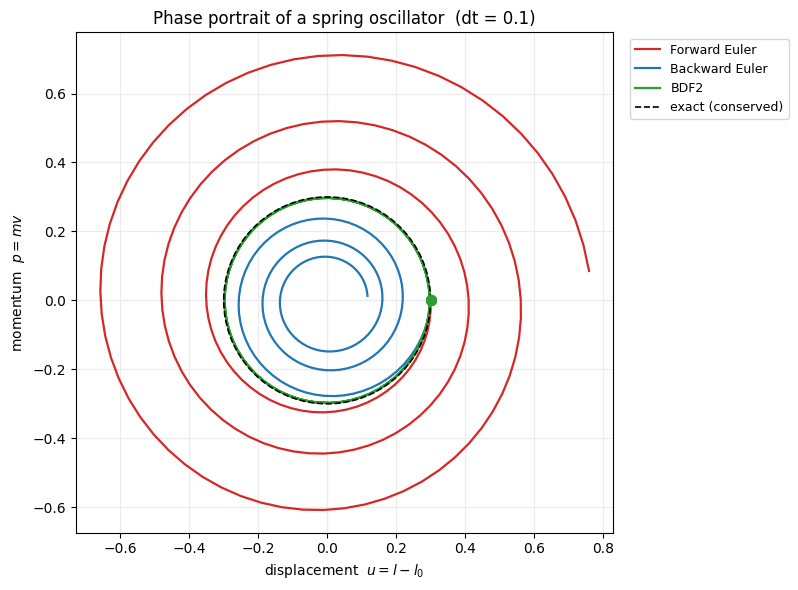

In [8]:
fig, ax = utils.phase_plot({s: np.column_stack([traj[s]["u"], MASS * traj[s]["v"]]) for s in SCHEMES},
                           xlabel="displacement  $u = l - l_0$", ylabel="momentum  $p = m v$",
                           title=f"Phase portrait of a spring oscillator  (dt = {DT_OSC})",
                           figsize=(8.4, 6))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(U0 * np.cos(theta), MASS * omega * U0 * np.sin(theta), "k--", lw=1.2, label="exact (conserved)")
ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)    # beside the axes, off the spirals
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "phase_portrait.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_phase_portrait.png"))
plt.show()

The same story as a time series of the total energy $H$, which every scheme *should* hold at its
initial value $\tfrac12 k u_0^2$ (dashed): explicit gains, implicit loses, BDF2 holds.

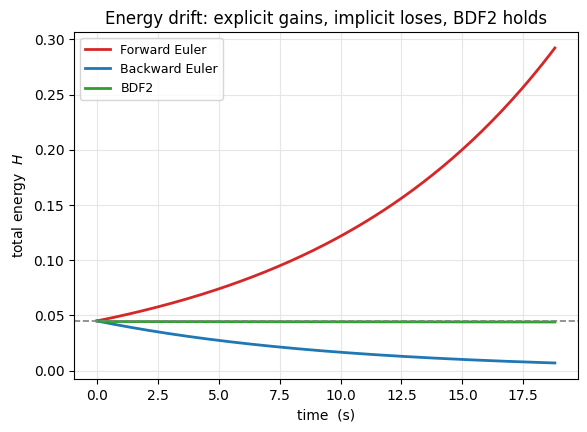

In [9]:
t_osc = np.arange(n_osc + 1) * DT_OSC
fig, ax = utils.line_plot(t_osc, {s: traj[s]["H"] for s in SCHEMES}, xlabel="time  (s)",
                          ylabel="total energy  $H$", colors=utils.INTEGRATOR_COLORS,
                          title="Energy drift: explicit gains, implicit loses, BDF2 holds")
ax.axhline(0.5 * K_SPRING * U0 ** 2, color="0.5", ls="--", lw=1.2)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy_drift.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_energy_drift.png"))
plt.show()

And the three integrators as actual oscillating springs, side by side: the explicit one's swing
grows, the implicit one's shrinks, BDF2's stays steady.

In [10]:
stride = max(1, (n_osc + 1) // OSC_FRAMES)
panels = []
for s in SCHEMES:
    states = [np.vstack([anchor, [[SPRING_L0 + u, 0.0]]]) for u in traj[s]["u"][::stride]]
    panels.append({"states": states, "E": E_spring, "title": s})

fig, anim = utils.animate_springs_grid(
    panels, lims=((-0.3, 2.0), (-0.4, 0.4)), fps=FPS, pin_pts=anchor, figsize=(13, 2.6),
    suptitle="Same spring, same dt: explicit grows, implicit shrinks, BDF2 steady")
fig.tight_layout()
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "oscillators.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "011_oscillators.mp4"))
plt.close(fig)
utils.embed_video(video)

## 3 &middot; A cable: many springs glued together

One spring resists only stretch. Chain many end to end and pin both ends, and the assembly
behaves like an elastic **cable**: under gravity the interior masses drop until spring tension
balances weight (an elastic catenary). Springs carry no *bending* stiffness, so this is a cable,
not a beam; bending is the next ingredient. In stacked positions $x$ the cable's potential
$\Phi$, and the objective of one Backward-Euler step, are

$$
\Phi(x) = \underbrace{\textstyle\sum_e \tfrac12 k\,(l_e-l_{0,e})^2}_{\text{springs}}
   + \underbrace{\tfrac12 x^\top Q x + b^\top x}_{\text{pins}}
   - \underbrace{f_g^\top x}_{\text{gravity}},
\qquad
\Phi(x) + \underbrace{\tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2}_{\text{inertia}},\quad \tilde x = 2x_n - x_{n-1}.
$$

The cable's constant operators, built once from simkit: the stacked edge-vector operator $J$
($d = Jx$), the rest lengths $l_0$, the lumped mass matrix $M$, the gravity force $f_g$ and the
soft-pin penalty $(Q, b)$ from `dirichlet_penalty`. The print checks that the lumped masses add
up to $\rho L$ and the weights to $\rho L g$.

In [11]:
J = sp.sparse.kron(simkit.edge_displacement_jacobian(X, E), sp.sparse.eye(dim)).tocsc()   # d = J x
l0 = simkit.edge_lengths(X, E).reshape(-1, 1)                        # rest length of every spring
vol = np.ones((len(E), 1))                                           # unit weight per spring
M_nodes = simkit.massmatrix(X, E, rho=RHO)                           # lumped mass of every node
M = sp.sparse.kron(M_nodes, sp.sparse.eye(dim)).tocsc()              # the same mass on every DOF
f_g = simkit.gravity_force(X, E, a=GRAVITY, rho=RHO).reshape(-1, 1)  # weight of every node
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)   # soft pins at both ends
print(f"J: {J.shape},  total mass = {M_nodes.sum():.3f} (rho L = {RHO * CABLE_LENGTH:.3f}),  "
      f"total weight = {f_g.sum():.3f} (rho L g = {RHO * CABLE_LENGTH * GRAVITY:.3f})")

J: (40, 42),  total mass = 4.000 (rho L = 4.000),  total weight = -39.200 (rho L g = -39.200)


`cable_system` closes over those operators and builds every term from simkit, one per line: the
springs with `mass_springs_*_z` on $d = Jx$, the pins as a quadratic, and gravity as a linear
term. Called without a previous state it is the quasi-static potential $\Phi$; given
$(x_n, x_{n-1})$ it adds the Backward-Euler inertia term (`kinetic_*_be`), so one function drives
both runs.

In [12]:
def cable_system(k, x_curr=None, x_prev=None, h=DT):
    """Cable potential (springs + pins + gravity) with spring stiffness k, in stacked positions x.

    Closes over the constant operators J, l0, vol, M, f_g, Q_pin, b_pin built above.
    Pass x_curr, x_prev to add the Backward-Euler inertia term."""
    ym = np.full((len(E), 1), k)
    dynamic = x_curr is not None

    def energy_func(x):
        E_spring = simkit.energies.mass_springs_energy_z(x, J, ym, vol, l0)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, h) if dynamic else 0.0
        E_total = E_spring + E_pin + E_gravity + E_inertia
        return E_total

    def gradient_func(x):
        g_spring = simkit.energies.mass_springs_gradient_z(x, J, ym, vol, l0)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, h) if dynamic else 0.0
        g_total = g_spring + g_pin + g_gravity + g_inertia
        return g_total

    def hessian_func(x):
        H_spring = simkit.energies.mass_springs_hessian_z(x, J, ym, vol, l0, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_inertia = simkit.energies.kinetic_hessian_be(M, h) if dynamic else 0.0 * M
        H_total = H_spring + H_pin + H_inertia                   # gravity is linear: no Hessian term
        return H_total

    return energy_func, gradient_func, hessian_func

Before trusting Newton with it, check the gradient of the full dynamic system (all four terms)
against central differences of its energy (`simkit.gradient_cfd`) at a random stretched state.
The relative error should be tiny.

In [13]:
x_rest = X.reshape(-1, 1).copy()
rng = np.random.default_rng(SEED)
noise = FD_NOISE * rng.standard_normal((n, dim))
noise[pin_idx] = 0.0                                             # keep the pins on target
x_test = (X + noise).reshape(-1, 1)

step_energy, step_gradient, _ = cable_system(K_CABLE, x_curr=x_rest, x_prev=x_rest)
g_fd = simkit.gradient_cfd(lambda y: np.array(step_energy(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
g = step_gradient(x_test)
print(f"relative gradient error vs central differences: {np.linalg.norm(g - g_fd.reshape(-1, 1)) / np.linalg.norm(g):.1e}")

relative gradient error vs central differences: 6.7e-08


### Without inertia: static equilibrium via Newton

No time, no velocity: minimize $\Phi$ from the flat chain, one Newton step at a time, recording
every iterate until the step is below `NEWTON_TOL`. The chain drops into its sag within a few
iterations while the energy gap $\Phi_k - \Phi^\star$ collapses to zero.

In [14]:
phi_energy, phi_gradient, phi_hessian = cable_system(K_CABLE)

x = x_rest.copy()
static_states, phi_hist, grad_hist = [X.copy()], [phi_energy(x)], [np.linalg.norm(phi_gradient(x))]
for _ in range(NEWTON_MAX_ITERS):
    x_next = newton_solver(x, phi_energy, phi_gradient, phi_hessian, max_iter=1)
    step = np.linalg.norm(x_next - x)
    x = x_next
    static_states.append(x.reshape(n, dim).copy())
    phi_hist.append(phi_energy(x))
    grad_hist.append(np.linalg.norm(phi_gradient(x)))
    if step < NEWTON_TOL:
        break
x_static = x.copy()
phi_star = phi_hist[-1]
energy_gap = np.array(phi_hist) - phi_star
print(f"static: {len(static_states) - 1} Newton iterations,  |grad| = {grad_hist[-1]:.1e},  "
      f"max sag = {-x_static.reshape(n, dim)[:, 1].min():.3f}")

fig, anim = utils.animate_springs_energy(
    static_states, E, np.arange(len(static_states)), {"potential": energy_gap}, rest=X, lims=CABLE_LIMS,
    xlabel="Newton iteration", ylabel=r"energy gap  $\Phi_k - \Phi^\star$", scene_title="static sag (gray = rest)",
    title="energy minimized", colors={"potential": utils.ENERGY_COLORS["potential"]}, pin_pts=X[pin_idx])
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "cable_static.mp4"), fps=NEWTON_FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "011_cable_static.mp4"))
plt.close(fig)
utils.embed_video(video)

static: 7 Newton iterations,  |grad| = 4.5e-11,  max sag = 1.258


The same solve on a log scale. The first step overshoots the sag (the line search only asks for
lower energy), so the gradient norm briefly rises; after that both curves fall ever faster, the
last steps quadratically, down to round-off.

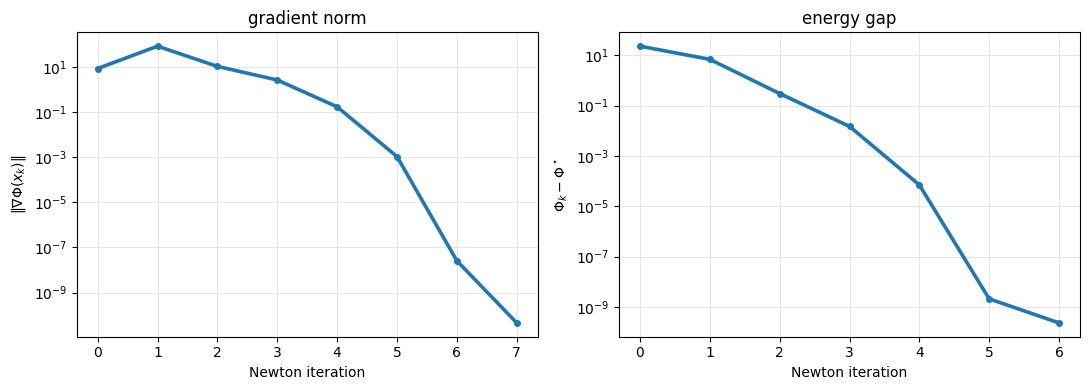

In [15]:
fig, (ax_g, ax_e) = plt.subplots(1, 2, figsize=(11, 4))
utils.residual_plot({"Newton": grad_hist}, ax=ax_g, markers=True, xlabel="Newton iteration",
                    ylabel=r"$\|\nabla\Phi(x_k)\|$", title="gradient norm")
utils.residual_plot({"Newton": energy_gap}, ax=ax_e, markers=True, xlabel="Newton iteration",
                    ylabel=r"$\Phi_k - \Phi^\star$", title="energy gap")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_newton_convergence.png"))
plt.show()

Two scalar fields of the cable: the lumped mass of each node (the two end nodes own half a spring
each, so they get half the mass), and the tension $k\,(l_e - l_{0,e})$ of each spring at the
static equilibrium. The tension is largest next to the pins, which carry the whole weight, and
smallest at the bottom.

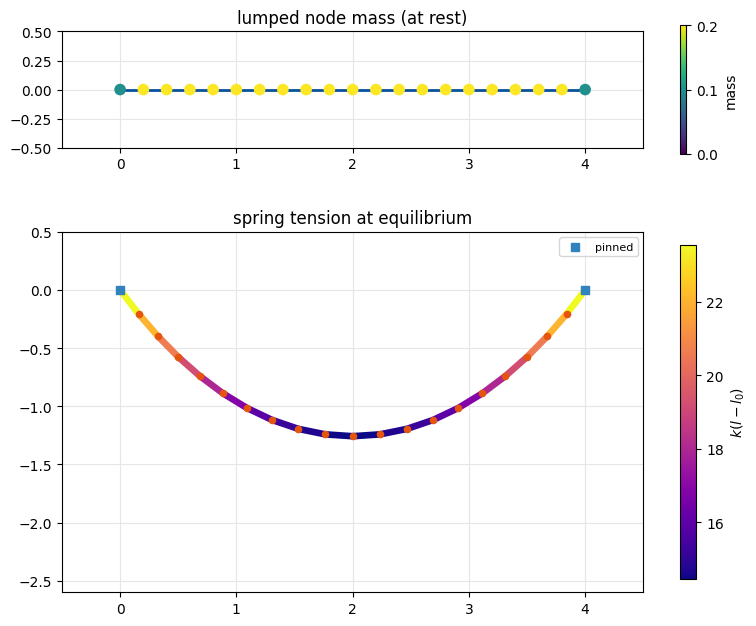

tension: 14.4 at the bottom  ->  23.5 next to the pins


In [16]:
m_nodes = M_nodes.diagonal()
X_static = x_static.reshape(n, dim)
tension = K_CABLE * (simkit.edge_lengths(X_static, E) - l0.ravel())

fig, (ax_m, ax_t) = plt.subplots(2, 1, figsize=(8, 6.6), gridspec_kw={"height_ratios": [1, 2.6]})
utils.plot_spring_network(ax_m, X, E, node_values=m_nodes, node_size=70, cmap="viridis",
                          title="lumped node mass (at rest)", label="mass", vmin=0.0,
                          lims=(CABLE_LIMS[0], (-0.5, 0.5)))
utils.plot_spring_network(ax_t, X_static, E, edge_values=tension, pins=pin_idx, node_size=20, lw=3,
                          cmap="plasma", title="spring tension at equilibrium", label=r"$k(l-l_0)$",
                          lims=CABLE_LIMS)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cable_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_cable_fields.png"))
plt.show()
print(f"tension: {tension.min():.1f} at the bottom  ->  {tension.max():.1f} next to the pins")

### With inertia: Backward-Euler dynamics from rest

Release the flat chain and march it `N_STEPS` steps: each step rebuilds `cable_system` with the
last two states and minimizes it with Newton, starting from the inertial guess $\tilde x$. The chain
falls, overshoots and oscillates, and Backward Euler's numerical damping rings the kinetic energy
down.

In [17]:
x_curr, x_prev = x_rest.copy(), x_rest.copy()                    # released from rest
dyn_states = [X.copy()]
ke_hist = [0.0]                                                  # kinetic energy
dist_hist = [np.linalg.norm((x_rest - x_static).reshape(n, dim), axis=1).max()]   # largest node distance to x*
total_hist = [phi_hist[0] - phi_star]                            # kinetic + potential above the minimum
for _ in range(N_STEPS):
    step_energy, step_gradient, step_hessian = cable_system(K_CABLE, x_curr=x_curr, x_prev=x_prev)
    x_tilde = simkit.energies.be_target(x_curr, x_prev, DT)
    x_next = newton_solver(x_tilde, step_energy, step_gradient, step_hessian, max_iter=STEP_ITERS,
                           tolerance=STEP_TOL)
    x_prev, x_curr = x_curr, x_next
    v = simkit.energies.velocity_be(x_curr, x_prev, DT)
    ke = 0.5 * (v.T @ M @ v).item()                              # kinetic energy
    pe = phi_energy(x_curr) - phi_star                           # potential above the minimum
    total = ke + pe
    dyn_states.append(x_curr.reshape(n, dim).copy())
    ke_hist.append(ke)
    dist_hist.append(np.linalg.norm((x_curr - x_static).reshape(n, dim), axis=1).max())
    total_hist.append(total)
t_hist = np.arange(N_STEPS + 1) * DT
print(f"dynamic: max sag during the run = {max(-s[:, 1].min() for s in dyn_states):.3f},  "
      f"final max sag = {-x_curr.reshape(n, dim)[:, 1].min():.3f} (static {-X_static[:, 1].min():.3f}),  "
      f"final KE = {ke_hist[-1]:.1e}")

fig, anim = utils.animate_springs_energy(
    dyn_states, E, t_hist, {"kinetic": ke_hist}, rest=X,
    lims=CABLE_LIMS, xlabel="time  (s)", ylabel="kinetic energy", scene_title="dynamic sag (Backward Euler)",
    title="kinetic energy rings down", colors={"kinetic": utils.ENERGY_COLORS["kinetic"]}, pin_pts=X[pin_idx])
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "cable_dynamic.mp4"), fps=CABLE_FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "011_cable_dynamic.mp4"))
plt.close(fig)
utils.embed_video(video)

dynamic: max sag during the run = 1.981,  final max sag = 1.268 (static 1.258),  final KE = 1.7e-04


### Same equilibrium, two roads

Quasi-static minimization (each Newton iterate held for a few frames) and full dynamics, side by
side: both settle to the **same** sagged shape.

In [18]:
static_frames = [static_states[min(i * len(static_states) // COMPARE_FRAMES, len(static_states) - 1)]
                 for i in range(COMPARE_FRAMES)]
dynamic_frames = [dyn_states[i] for i in np.linspace(0, N_STEPS, COMPARE_FRAMES).astype(int)]

fig, anim = utils.animate_springs_grid(
    [{"states": static_frames, "E": E, "title": "without inertia (Newton iterates)"},
     {"states": dynamic_frames, "E": E, "title": "with inertia (Backward Euler)"}],
    lims=CABLE_LIMS, fps=FPS, pin_pts=X[pin_idx], figsize=(11, 3.8),
    suptitle="Cable sag: minimization vs dynamics settle to the same shape")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "cable_compare.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "011_cable_compare.mp4"))
plt.close(fig)
utils.embed_video(video)

Quantitatively: the largest vertex distance between the dynamic cable and the static equilibrium,
and the total energy above the static minimum, $\tfrac12 v^\top M v + \Phi(x) - \Phi^\star$. Both
decay toward zero, and the total energy never increases: Backward Euler only removes energy.

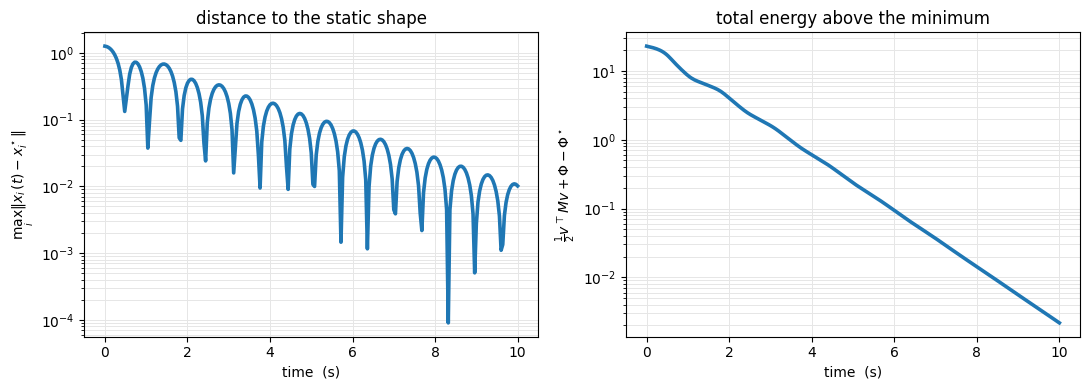

total energy monotone (up to round-off): True,  final distance = 1.0e-02


In [19]:
fig, (ax_d, ax_h) = plt.subplots(1, 2, figsize=(11, 4))
utils.residual_plot({"dynamic": dist_hist}, t_hist, ax=ax_d, xlabel="time  (s)",
                    ylabel=r"$\max_i \|x_i(t) - x_i^\star\|$", title="distance to the static shape")
utils.residual_plot({"dynamic": total_hist}, t_hist, ax=ax_h, xlabel="time  (s)",
                    ylabel=r"$\frac{1}{2}v^\top M v + \Phi - \Phi^\star$", title="total energy above the minimum")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cable_settling.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_cable_settling.png"))
plt.show()
print(f"total energy monotone (up to round-off): {bool(np.all(np.diff(total_hist) <= MONOTONE_TOL))},  "
      f"final distance = {dist_hist[-1]:.1e}")

Finally, a quick parameter study: re-solve the static sag for each stiffness in `K_SWEEP`. Softer
springs stretch more and sag deeper.

k =    100:  max sag = 2.374
k =    400:  max sag = 1.258
k =   1600:  max sag = 0.744


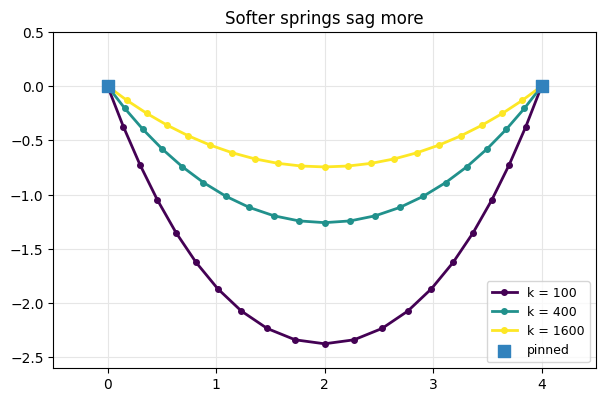

In [20]:
sags = {}
for k in K_SWEEP:
    energy_k, gradient_k, hessian_k = cable_system(k)
    x_k = newton_solver(x_rest.copy(), energy_k, gradient_k, hessian_k, max_iter=NEWTON_MAX_ITERS, tolerance=NEWTON_TOL)
    sags[k] = x_k.reshape(n, dim)
    print(f"k = {k:6g}:  max sag = {-sags[k][:, 1].min():.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
utils.setup_axes(ax, *CABLE_LIMS, title="Softer springs sag more")
cmap = plt.get_cmap("viridis")
for j, (k, X_k) in enumerate(sags.items()):
    ax.plot(X_k[:, 0], X_k[:, 1], "-o", ms=4, lw=2, color=cmap(j / max(1, len(sags) - 1)), label=f"k = {k:g}")
ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=70, marker="s", color=utils.PIN_C, zorder=5, label="pinned")
ax.legend(fontsize=9, loc="lower right")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cable_stiffness.png"),
                              copy_to=os.path.join(MEDIA_DIR, "011_cable_stiffness.png"))
plt.show()

### Takeaways
* A spring stores $\tfrac12 k (l-l_0)^2$; differentiating gives the linear **Hooke force**
  $-k(l-l_0)$.
* With inertia the integrator decides the energy behaviour: **Forward Euler** gains it (unstable),
  **Backward Euler** bleeds it (damped), **BDF2** nearly conserves it, vivid in the phase portrait.
* Many springs make an elastic **cable**; gravity sags it into an elastic catenary, and the
  quasi-static minimization and the dynamic Backward-Euler run settle to the **same** equilibrium.